<a href="https://colab.research.google.com/github/cysorianoc/Hugging_Face/blob/main/Notebook_8_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 9: Segmentation

- In the classroom, the libraries are already installed for you.
- If you would like to run this code on your own machine, you can install the following:

```
    !pip install transformers
    !pip install gradio
    !pip install timm
    !pip install torchvision
```

We will use segment anything model from Meta.

## What is Segmentation Mask Generation ?

In this image we can see an example of image segmentation. The model predicts labels for each pixel in the image, sky, bridge, ground, mountains.

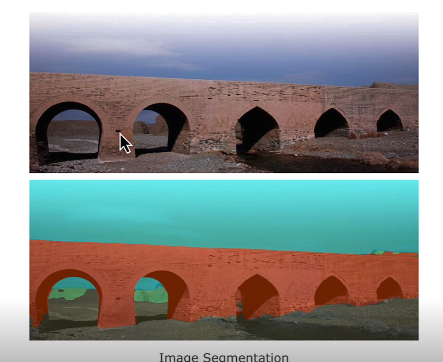

**In** segmentation mask generation users can perform visual prompting by guiding the model where to perform the segemntation mask of an object of interest. In this case there are no labels, we get the mask of the object of interest.

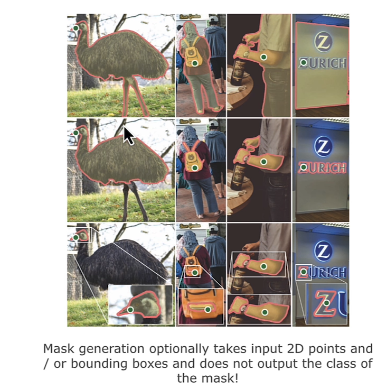

We can also perform automatic mask generation. by sampling some points in an image and get relevant segmentation masks on an image.

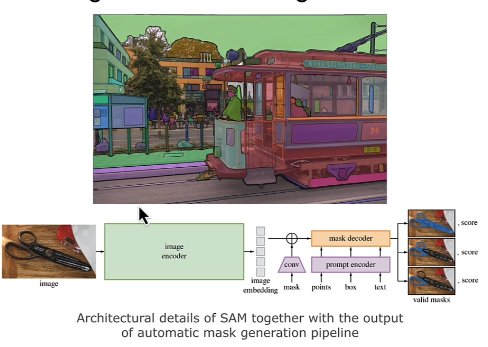

In this notebook we will use a compressed version of the model called distiled SAM to reduce the use of computer resources.

- Here is some code that suppresses warning messages.

In [1]:
from transformers.utils import logging
logging.set_verbosity_error()

### Mask Generation with SAM

The [Segment Anything Model (SAM)](https://segment-anything.com) model was released by Meta AI.

In [2]:
from transformers import pipeline

In [3]:
sam_pipe = pipeline("mask-generation",
    "Zigeng/SlimSAM-uniform-77")

config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 38.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

Info about [Zigeng/SlimSAM-uniform-77](https://huggingface.co/Zigeng/SlimSAM-uniform-77)

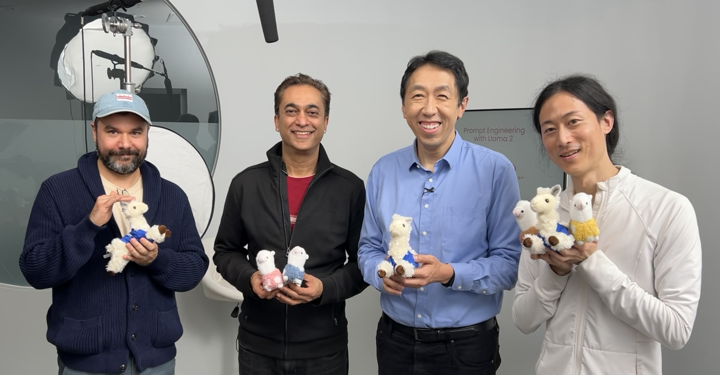

In [9]:
from PIL import Image
from io import BytesIO
import requests

# We can import the image from github repository
url="https://github.com/cysorianoc/Hugging_Face/raw/main/meta_llamas.jpg"
response=requests.get(url)

raw_image = Image.open(BytesIO(response.content))
raw_image.resize((720, 375))

- Running this will take some time
- The higher the value of 'points_per_batch', the more efficient pipeline inference will be

In [10]:
output = sam_pipe(raw_image, points_per_batch=32)

In [11]:
# Some auxiliary functions to visualize the results

import numpy as np
import torch
import matplotlib.pyplot as plt

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3),
                                np.array([0.6])],
                               axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0),
                               w,
                               h, edgecolor='green',
                               facecolor=(0,0,0,0),
                               lw=2))

def show_boxes_on_image(raw_image, boxes):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    for box in boxes:
      show_box(box, plt.gca())
    plt.axis('on')
    plt.show()

def show_points_on_image(raw_image, input_points, input_labels=None):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)
    if input_labels is None:
      labels = np.ones_like(input_points[:, 0])
    else:
      labels = np.array(input_labels)
    show_points(input_points, labels, plt.gca())
    plt.axis('on')
    plt.show()

def show_points_and_boxes_on_image(raw_image,
                                   boxes,
                                   input_points,
                                   input_labels=None):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)
    if input_labels is None:
      labels = np.ones_like(input_points[:, 0])
    else:
      labels = np.array(input_labels)
    show_points(input_points, labels, plt.gca())
    for box in boxes:
      show_box(box, plt.gca())
    plt.axis('on')
    plt.show()


def show_points_and_boxes_on_image(raw_image,
                                   boxes,
                                   input_points,
                                   input_labels=None):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)
    if input_labels is None:
      labels = np.ones_like(input_points[:, 0])
    else:
      labels = np.array(input_labels)
    show_points(input_points, labels, plt.gca())
    for box in boxes:
      show_box(box, plt.gca())
    plt.axis('on')
    plt.show()


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0],
               pos_points[:, 1],
               color='green',
               marker='*',
               s=marker_size,
               edgecolor='white',
               linewidth=1.25)
    ax.scatter(neg_points[:, 0],
               neg_points[:, 1],
               color='red',
               marker='*',
               s=marker_size,
               edgecolor='white',
               linewidth=1.25)


def fig2img(fig):
    """Convert a Matplotlib figure to a PIL Image and return it"""
    import io
    buf = io.BytesIO()
    fig.savefig(buf)
    buf.seek(0)
    img = Image.open(buf)
    return img


def show_mask_on_image(raw_image, mask, return_image=False):
    if not isinstance(mask, torch.Tensor):
      mask = torch.Tensor(mask)

    if len(mask.shape) == 4:
      mask = mask.squeeze()

    fig, axes = plt.subplots(1, 1, figsize=(15, 15))

    mask = mask.cpu().detach()
    axes.imshow(np.array(raw_image))
    show_mask(mask, axes)
    axes.axis("off")
    plt.show()

    if return_image:
      fig = plt.gcf()
      return fig2img(fig)




def show_pipe_masks_on_image(raw_image, outputs):
  plt.imshow(np.array(raw_image))
  ax = plt.gca()
  for mask in outputs["masks"]:
      show_mask(mask, ax=ax, random_color=True)
  plt.axis("off")
  plt.show()



/tmp/ipykernel_1296/134160109.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


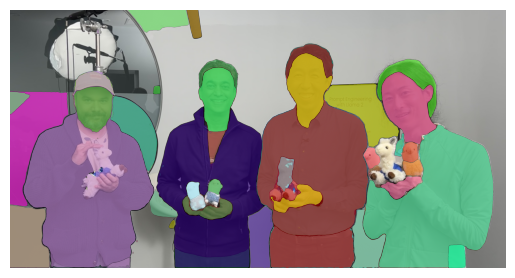

In [12]:
show_pipe_masks_on_image(raw_image, output)

_Note:_ The colors of segmentation, that you will get when running this code, might be different than the ones you see in the video.

From the results we can see the model was able to segment or identify different regions of interest in the image, some of the llamas and other objects.

The issue with this pipeline is we need to iterate over all the points and post-process the generated masks, which may be slow for some applications. Also even running this code on GPU it took some time to get the results.

### Faster Inference: Infer an Image and a Single Point

Instead of using pipelines we import the model class from transformers.

In [13]:
from transformers import SamModel, SamProcessor

In [14]:
from transformers import SamModel, SamProcessor

# 1. THE BRAIN (Model):
# Loads the pre-trained weights that perform the actual image segmentation.
model = SamModel.from_pretrained(
    "Zigeng/SlimSAM-uniform-77"
)

# 2. THE TRANSLATOR (Processor):
# Formats raw human inputs (images, coordinate points, or bounding boxes)
# into the mathematical tensors the model understands.
processor = SamProcessor.from_pretrained(
    "Zigeng/SlimSAM-uniform-77"
)

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

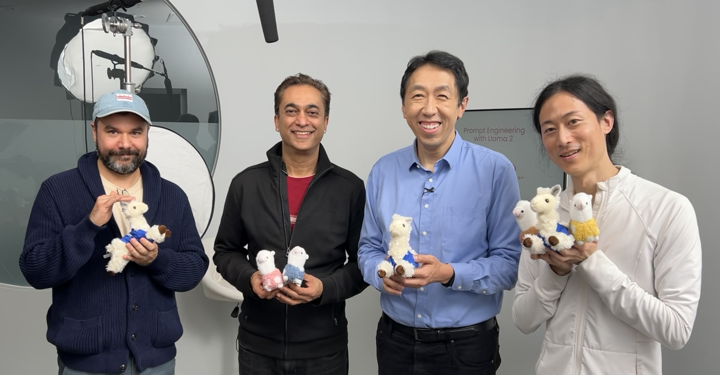

In [15]:
raw_image.resize((720, 375))

In [17]:
# Notice thet raw image size is the same as the original, the resize was just for display
raw_image.size

(2880, 1500)

- Segment the blue shirt Andrew is wearing.
- Give any single 2D point that would be in that region (blue shirt).

In [18]:
# The point 0,0 of the photo is at the top left

input_points = [[[1600, 700]]]

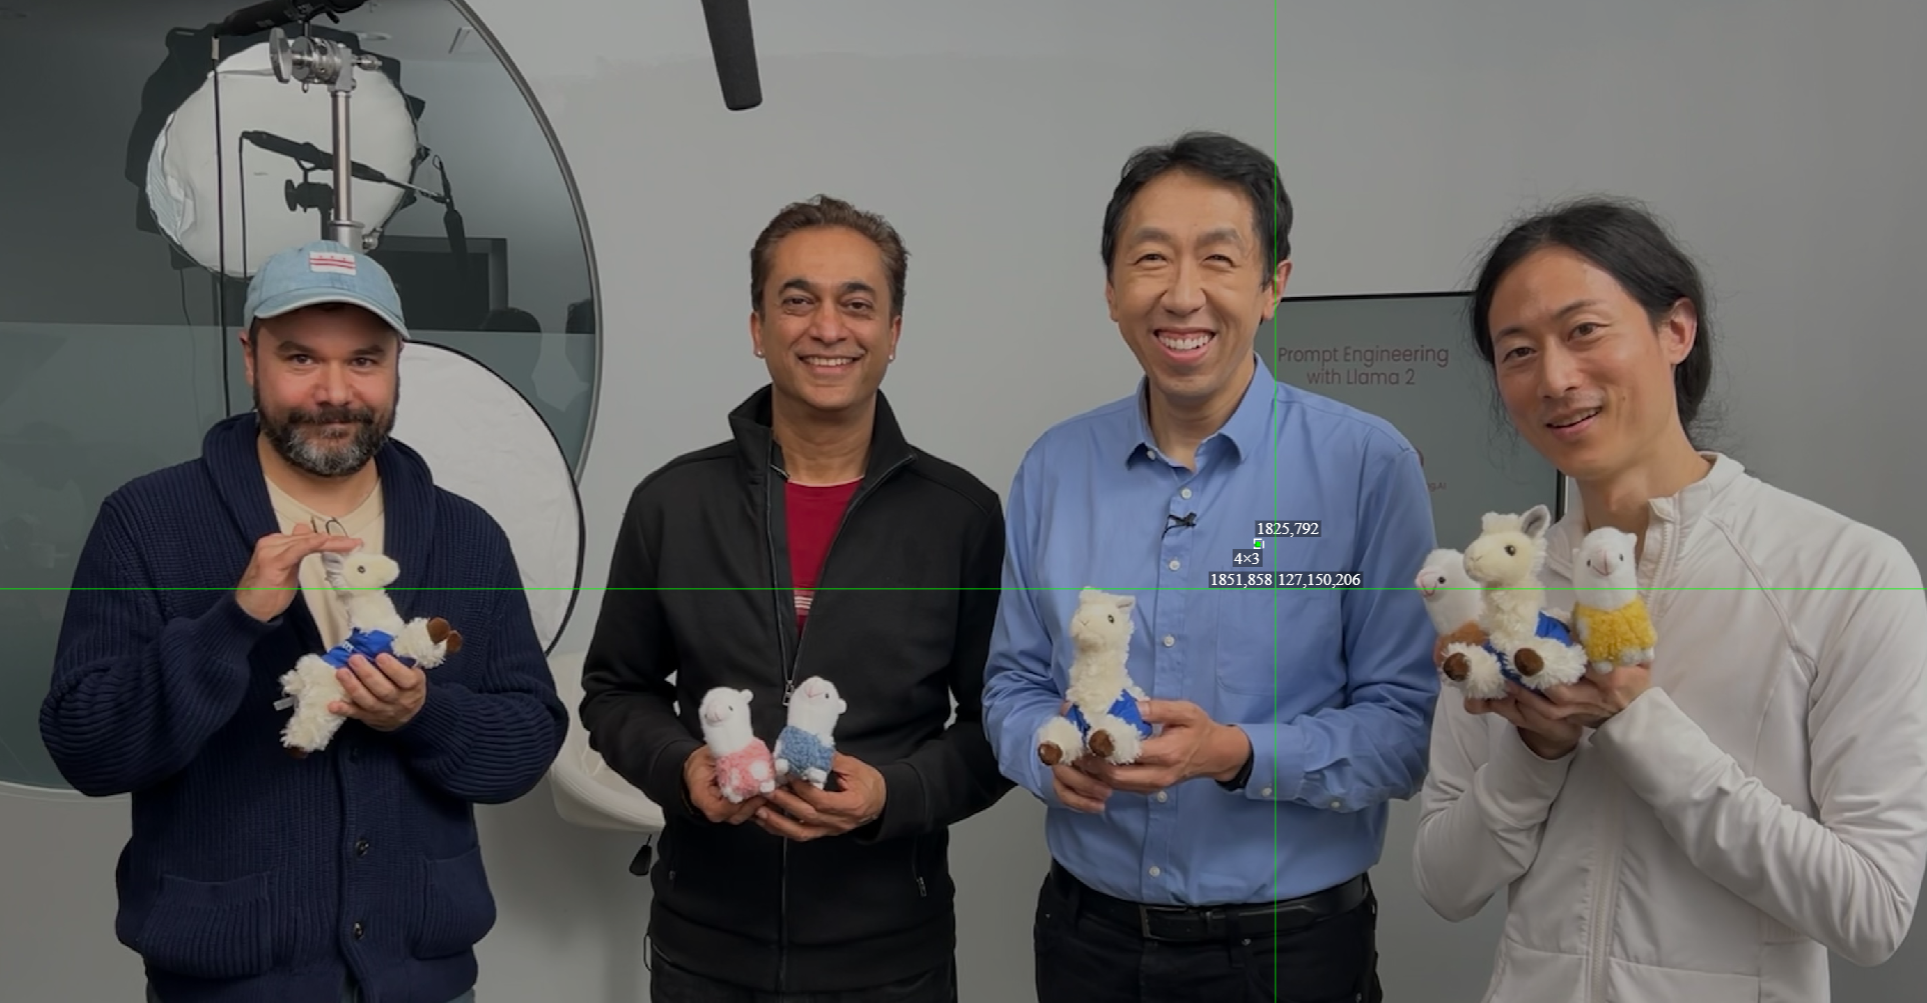

- Create the input using the image and the single point.
- `return_tensors="pt"` means to return PyTorch Tensors.

In [19]:
# THE TRANSLATOR AT WORK:
# Converting your raw data into machine-readable math
inputs = processor(
    raw_image,                 # Raw Input 1: The original image (usually a PIL Image)
    input_points=input_points, # Raw Input 2: The x/y coordinates you just set
    return_tensors="pt"        # Output Format: "pt" means PyTorch tensors (the exact language the Model speaks)
)

- Given the inputs, get the output from the model.

In [20]:
import torch

In [21]:
# 3. READ-ONLY MODE (Inference):
# torch.no_grad() disables "learning" (gradient tracking) since we are only predicting.
# This makes the process much faster and uses way less memory.
with torch.no_grad():

    # THE BRAIN AT WORK:
    # The '**' (unpacking operator) takes the dictionary of PyTorch tensors
    # we got from the Translator and feeds them in as individual arguments.
    outputs = model(**inputs)

In [22]:
# 4. REVERSE TRANSLATION (Post-processing):
# The Model always processes images at a fixed, square size (e.g., 1024x1024).
# This scales the raw output mask back to the exact dimensions of your original photo.
predicted_masks = processor.image_processor.post_process_masks(
    outputs.pred_masks,             # The raw, low-res mask output by the Brain
    inputs["original_sizes"],       # Target size: The dimensions of your starting image
    inputs["reshaped_input_sizes"]  # Current size: The dimensions used during the Model's math
)

 Length of `predicted_masks` corresponds to the number of images that are used in the input.

In [23]:
len(predicted_masks)
# The number of processed images

1

- Inspect the size of the first ([0]) predicted mask

In [24]:
predicted_mask = predicted_masks[0]
predicted_mask.shape

torch.Size([1, 3, 1500, 2880])

The model predicts three segmentation maskc with several prediction scores. We measure the confidence of the prediction

In [25]:
outputs.iou_scores

tensor([[[0.9583, 0.9552, 0.9580]]])

/tmp/ipykernel_1296/134160109.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


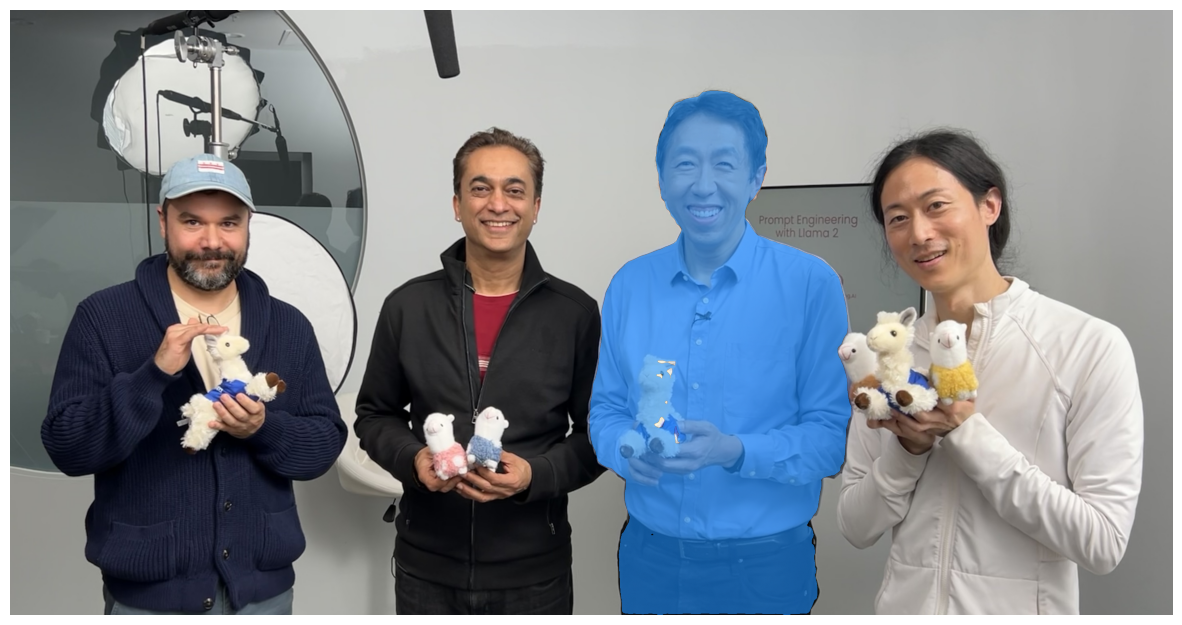

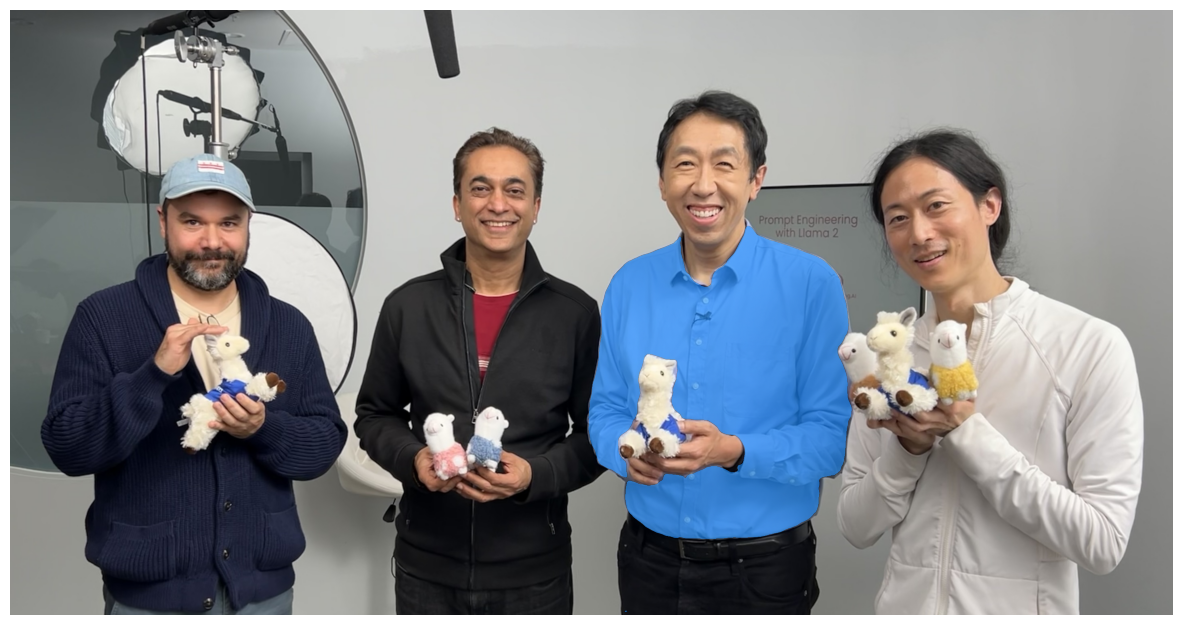

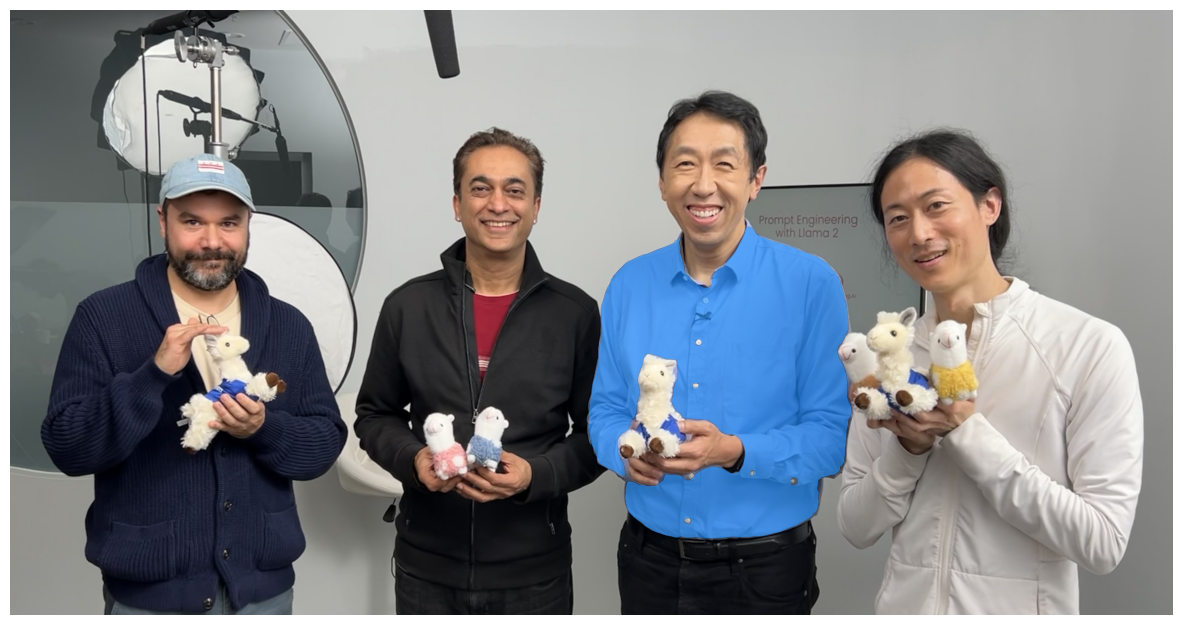

In [26]:
# We use the previous defined function
for i in range(3):
    show_mask_on_image(raw_image, predicted_mask[:, i])

We see the first image segmented the shirt and the person. The two others managed to segment only the shirt. We can pass more points on the same region of interest for better predictions.

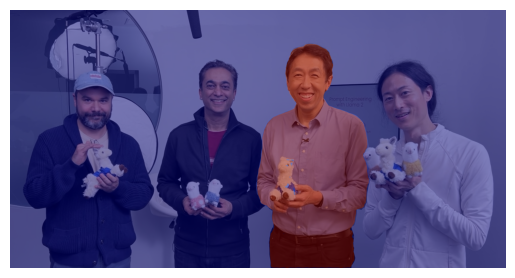

In [27]:
# Alternatively we can plot the result with simple code no def function
import matplotlib.pyplot as plt

# Display the original image
plt.imshow(raw_image)

# Overlay the predicted mask with some transparency
plt.imshow(predicted_mask[0, 0], alpha=0.5, cmap="jet")

plt.axis("off")
plt.show()

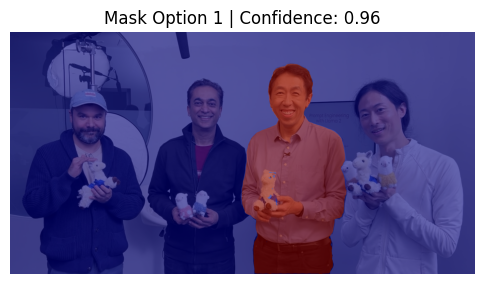

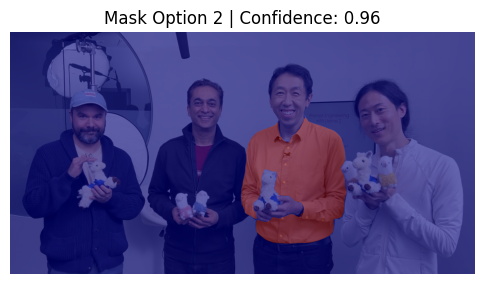

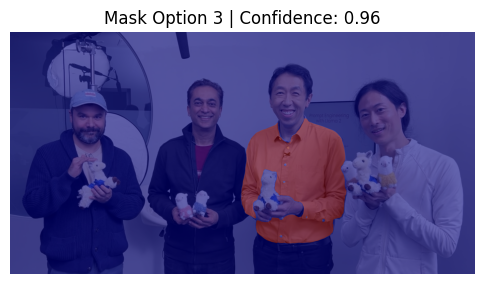

In [30]:
import matplotlib.pyplot as plt

# 1. UNPACK THE RESULTS:
# We only fed in one image and one point prompt, so we extract the first item [0, 0]
# from the model's batches of scores and masks.
scores = outputs.iou_scores[0, 0]
masks = predicted_masks[0][0]

# 2. PLOT EACH GUESS:
# Loop through the 3 mask options the model generated
for i in range(len(scores)):
    plt.figure(figsize=(6, 6))

    # Base layer: Show the original raw photo
    # (Removed cmap="gray" so your color photos show up in color)
    plt.imshow(raw_image)

    # Overlay layer: Draw the mask on top
    # We must convert the mask from a PyTorch tensor to a NumPy array for matplotlib.
    # 'jet' or 'viridis' are great colormaps for high contrast over photos.
    plt.imshow(masks[i].cpu().numpy(), alpha=0.6, cmap="jet")

    # Display the model's confidence score (IoU score) for this specific mask
    plt.title(f"Mask Option {i+1} | Confidence: {scores[i]:.2f}")

    # Clean up the plot by hiding the graph axes
    plt.axis("off")
    plt.show()

## Depth Estimation with DPT

- This model was introduced in the paper [Vision Transformers for Dense Prediction](https://arxiv.org/abs/2103.13413) by Ranftl et al. (2021) and first released in [isl-org/DPT](https://github.com/isl-org/DPT).

This model stands for Dense Prediction Transformer
It allows to estimate depths from an image.


In [31]:
from transformers import pipeline

# THE MANAGER (Pipeline):
# A pipeline is an all-in-one wrapper. It automatically builds both the Brain (Model)
# and the Translator (Processor) behind the scenes, so you don't have to.
depth_estimator = pipeline(
    task="depth-estimation",       # The Job: Tell the manager exactly what kind of task to perform.
    model="Intel/dpt-hybrid-midas" # The Worker: Specify which pre-trained model to hire for the job.
)

config.json:   0%|          | 0.00/9.88k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  490MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  490MB            

model.safetensors: downloading bytes:           |  0.00B            

Info about ['Intel/dpt-hybrid-midas'](https://huggingface.co/Intel/dpt-hybrid-midas)

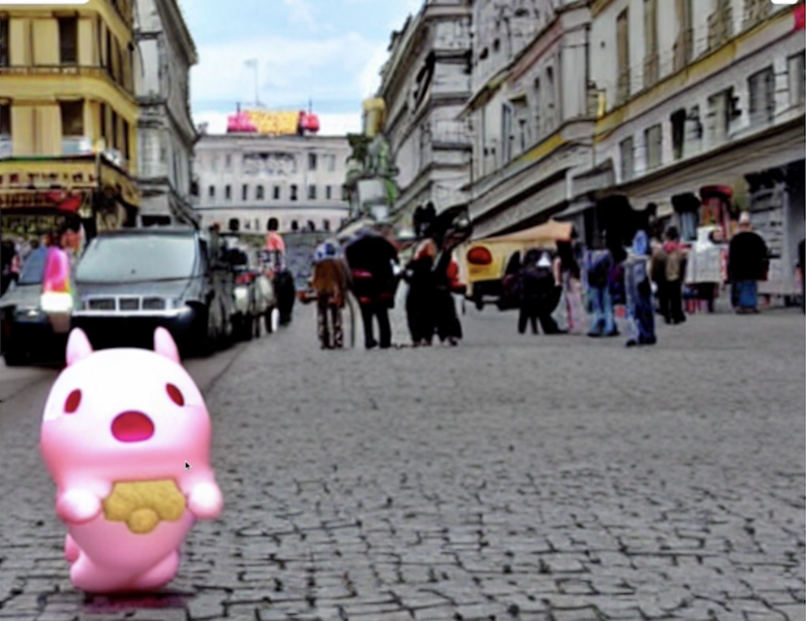

In [33]:
# We can import the image from github repository
url="https://github.com/cysorianoc/Hugging_Face/raw/main/gradio_tamagochi_vienna.png"
response=requests.get(url)

raw_image = Image.open(BytesIO(response.content))
raw_image.resize((806, 621))

In [34]:
raw_image.size

(1612, 1242)

- If you'd like to generate this image or something like it, check out the short course on [Gradio](https://www.deeplearning.ai/short-courses/building-generative-ai-applications-with-gradio/) and go to the lesson "Image Generation App".

In [38]:
output = depth_estimator(raw_image)

In [36]:
output
# So we get a tensor with the predicted depths

{'predicted_depth': tensor([[ 248.2257,  248.3294,  248.8255,  ...,  467.9399,  446.8859,
           442.7385],
         [ 248.0988,  248.2124,  248.7596,  ...,  477.6361,  458.2722,
           454.4572],
         [ 247.1509,  247.3060,  248.0667,  ...,  508.7196,  494.8194,
           492.0782],
         ...,
         [3039.8904, 3040.2507, 3042.0847,  ..., 3285.1335, 3283.1543,
          3282.7649],
         [3037.7229, 3038.2397, 3040.8816,  ..., 3288.0737, 3286.3477,
          3286.0032],
         [3037.4036, 3037.9670, 3040.8486,  ..., 3289.0803, 3287.4038,
          3287.0684]]),
 'depth': <PIL.Image.Image image mode=L size=1612x1242>}

- Post-process the output image to resize it to the size of the original image.

In [40]:
output["predicted_depth"].shape
# note that output dimensions are reversed we get height and width
# If we see the previous line the image is read as width and height

torch.Size([1242, 1612])

In [42]:
# THE SHAPE SHIFTER (Formatting for PyTorch functions):
# The model outputs a basic 2D grid of depths, but PyTorch's interpolate tool
# strictly requires a 4D volume to do its math (Batch, Channels, Height, Width).
prediction = torch.nn.functional.interpolate(

    # 1. THE 4D TRICK:
    # .unsqueeze(0) artificially adds a dimension. We do it twice to transform
    # our 2D map (H, W) -> 3D (1 channel, H, W) -> 4D (1 batch, 1 channel, H, W).
    output["predicted_depth"].unsqueeze(0).unsqueeze(0),

    # 2. THE FLIP (PIL vs. PyTorch):
    # PIL (your raw image) reads dimensions as (Width, Height).
    # PyTorch strictly reads as (Height, Width).
    # [::-1] simply reads the tuple backwards to fix this conflict.
    size=raw_image.size[::-1],

    # 3. SPATIAL INTERPOLATION:
    # As you scale up a low-res grid, "bicubic" smoothly estimates the missing
    # data points between pixels, giving you continuous contours instead of blocky edges.
    mode="bicubic",
    align_corners=False
)

In [43]:
prediction.shape
# Explanation
# 1 number of photos
# 1 number of channels: depth map has one channel as is a depth value
# 1242, 1612 image height and width

torch.Size([1, 1, 1242, 1612])

In [44]:
# PIL returns image size as (width, height),
# but interpolate() expects (height, width),
# so we reverse the order using [::-1]
# This is the explanation of previous code line
raw_image.size[::-1]

(1242, 1612)

In [46]:
prediction

tensor([[[[ 248.2257,  248.3294,  248.8255,  ...,  467.9399,  446.8859,
            442.7385],
          [ 248.0988,  248.2124,  248.7596,  ...,  477.6361,  458.2722,
            454.4572],
          [ 247.1509,  247.3060,  248.0667,  ...,  508.7196,  494.8194,
            492.0782],
          ...,
          [3039.8904, 3040.2507, 3042.0847,  ..., 3285.1335, 3283.1543,
           3282.7649],
          [3037.7229, 3038.2397, 3040.8816,  ..., 3288.0737, 3286.3477,
           3286.0032],
          [3037.4036, 3037.9670, 3040.8486,  ..., 3289.0803, 3287.4038,
           3287.0684]]]])

- Normalize the predicted tensors (between 0 and 255) so that they can be displayed.

In [47]:
import numpy as np

In [48]:
import numpy as np
from PIL import Image

# 1. THE REVERSE SHAPE SHIFTER (Cleanup):
# squeeze() removes the extra '1' dimensions we added earlier for the Batch and Channel.
# This brings the 4D tensor back down to a flat 2D grid (Height, Width).
# .numpy() kicks it out of PyTorch and back into standard Python.
output = prediction.squeeze().numpy()

# 2. THE DARKROOM (Normalization):
# The model's raw depth predictions are arbitrary decimal numbers.
# Dividing by np.max() scales everything to a percentage between 0 and 1.
# Multiplying by 255 stretches those percentages across a standard 0-255 pixel range.
# .astype("uint8") chops off the decimals, leaving the 8-bit whole numbers images require.
formatted = (output * 255 / np.max(output)).astype("uint8")

# 3. THE FINAL PRINT:
# Wraps the formatted NumPy array back into a standard PIL Image object,
# meaning you can now easily display it, save it, or pass it to other libraries.
depth = Image.fromarray(formatted)

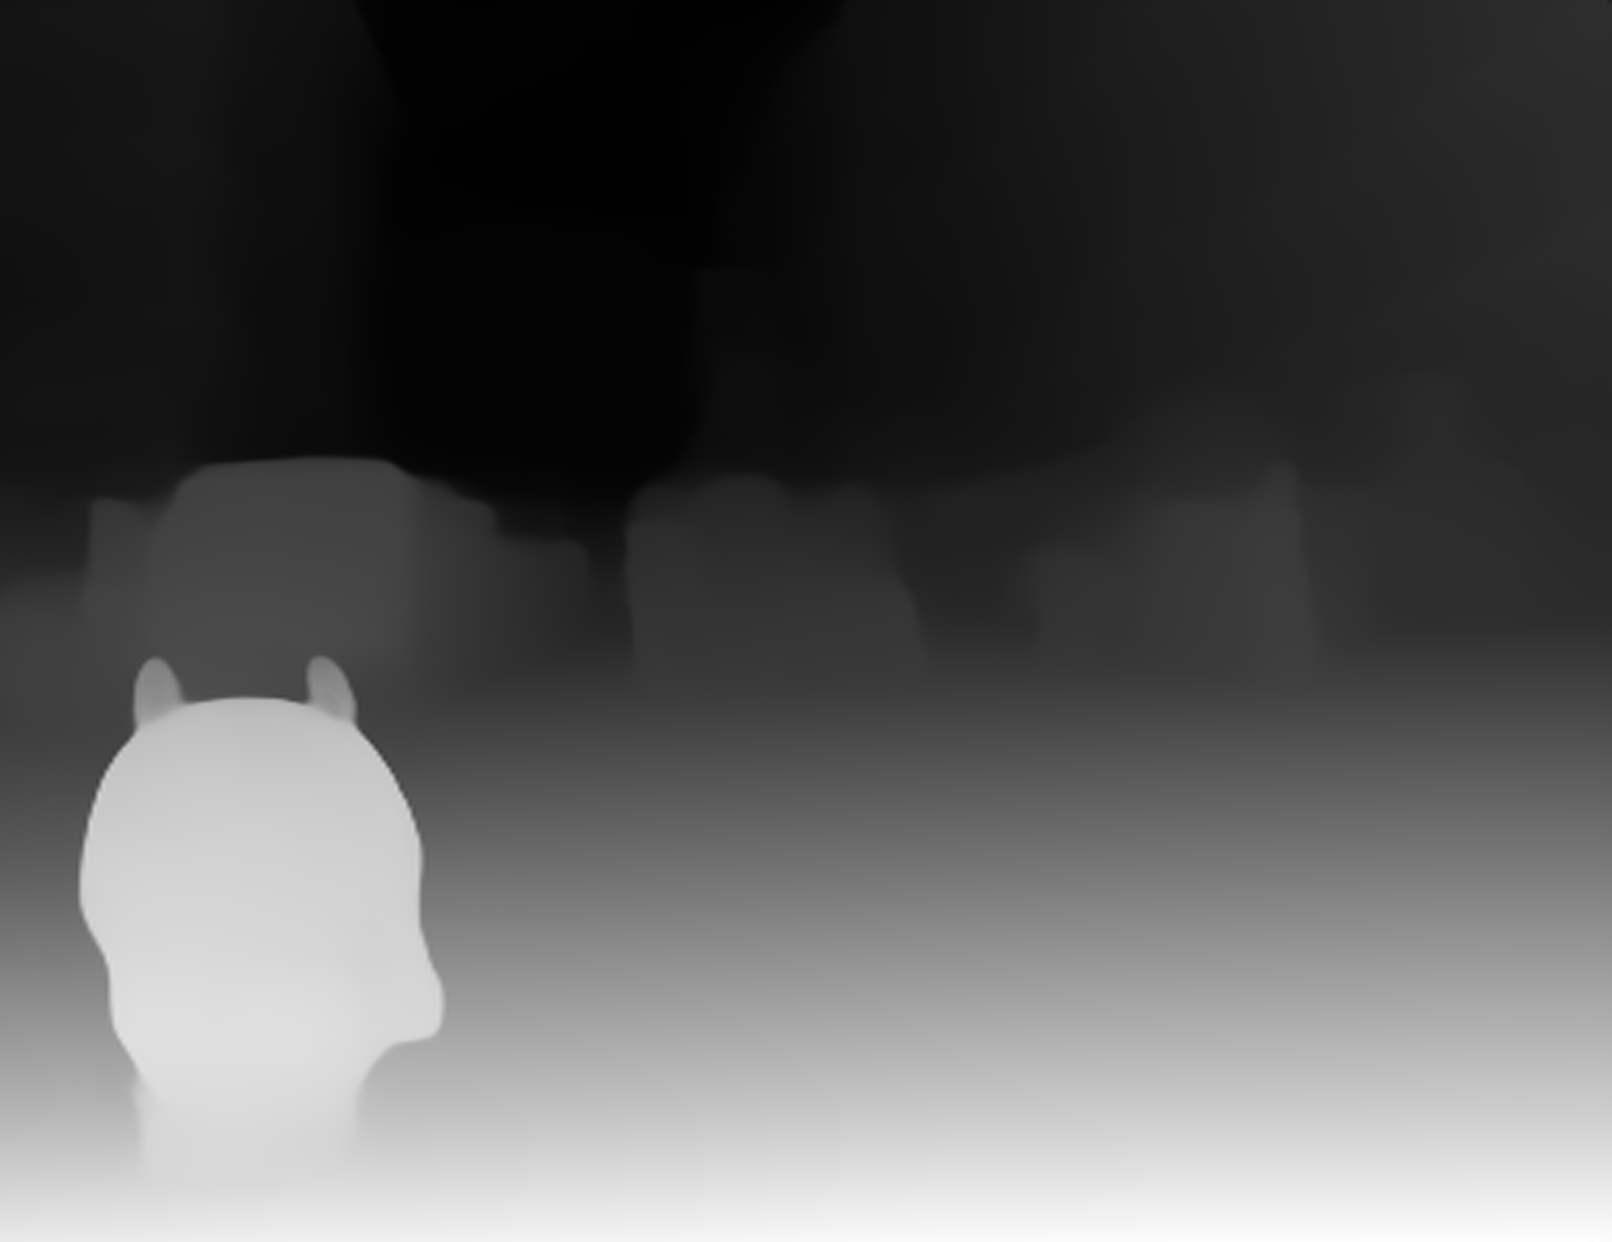

In [49]:
depth

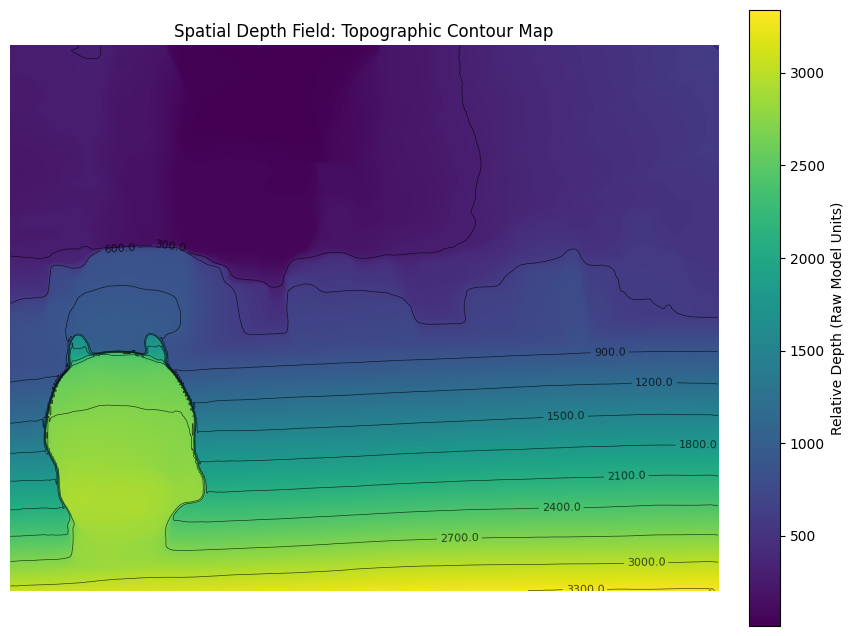

In [50]:
import matplotlib.pyplot as plt

# THE SURVEYOR'S VIEW:
# We treat the depth array as a 3D surface map rather than a simple photograph.
plt.figure(figsize=(10, 8))

# 1. THE CONTINUOUS BASE MAP (Heatmap):
# We plot the raw floating-point 'output', not the 0-255 version.
# 'viridis' is the scientific standard colormap because it represents numerical gradients evenly.
base_plot = plt.imshow(output, cmap="viridis")

# 2. THE ISOCONTOURS:
# plt.contour draws topological lines connecting points of exactly equal depth.
# levels=12 automatically calculates 12 evenly spaced data steps across your min/max range.
contours = plt.contour(output, levels=12, colors="black", linewidths=0.5, alpha=0.7)

# 3. THE ELEVATION LABELS:
# clabel prints the actual numerical depth values directly onto the contour lines.
# fmt="%1.1f" keeps the labels clean by rounding to one decimal place.
plt.clabel(contours, inline=True, fontsize=8, fmt="%1.1f")

# 4. THE DATA SCALE:
# A scientific plot needs a legend. This attaches a colorbar scaled to the raw data range.
# (fraction and pad just keep the bar sized nicely next to the image).
plt.colorbar(base_plot, label="Relative Depth (Raw Model Units)", fraction=0.046, pad=0.04)

plt.title("Spatial Depth Field: Topographic Contour Map")
plt.axis("off")
plt.show()

### Demo using Gradio

### Troubleshooting Tip
- Note, in the classroom, you may see the code for creating the Gradio app run indefinitely.
  - This is specific to this classroom environment when it's serving many learners at once, and you won't wouldn't experience this issue if you run this code on your own machine.
- To fix this, please restart the kernel (Menu Kernel->Restart Kernel) and re-run the code in the lab from the beginning of the lesson.

In [51]:
import os
import gradio as gr
from transformers import pipeline

In [68]:
def launch(input_image):
    # 1. THE MANAGER (Inference):
    # Hand the raw image to the pipeline.
    out = depth_estimator(input_image)

    # 2. THE SHAPE SHIFTER (Spatial Interpolation):
    prediction = torch.nn.functional.interpolate(
        # THE FIX: Changed 'output' to 'out' to match the variable created in Step 1
        out["predicted_depth"].unsqueeze(0).unsqueeze(0),
        size=input_image.size[::-1],  # Flip PIL's (W,H) to PyTorch's (H,W)
        mode="bicubic",               # Smooth out the gradients between pixels
        align_corners=False,
    )

    # 3. THE DARKROOM (Normalization):
    # Flatten the tensor back down to a 2D grid and move it out of PyTorch (.numpy()).
    output = prediction.squeeze().numpy()

    # Scale the arbitrary decimal depths into standard 8-bit image pixels (0-255).
    formatted = (output * 255 / np.max(output)).astype("uint8")

    # Wrap the numbers back into a standard PIL Image object, ready to be shown or saved.
    depth = Image.fromarray(formatted)

    return depth

In [69]:
iface = gr.Interface(launch,
                     inputs=gr.Image(type='pil'),
                     outputs=gr.Image(type='pil'))

In [70]:
iface.launch(share=True, server_port=8081)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9bf86f84a5fc52e5c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [71]:
iface.close()

Closing server running on port: 8081


### Close the app
- Remember to call `.close()` on the Gradio app when you're done using it.

### Try it yourself!
- Try this model with your own images!

In [74]:
import torch
from PIL import Image
from transformers import pipeline
import matplotlib.pyplot as plt
import io
import gradio as gr

# 0. THE MANAGER (Pipeline)
depth_estimator = pipeline(task="depth-estimation", model="Intel/dpt-hybrid-midas")

def launch_simple_contour(input_image):
    # 1. INFERENCE
    out = depth_estimator(input_image)

    # 2. THE SHAPE SHIFTER (Resize back to original photo size)
    prediction = torch.nn.functional.interpolate(
        out["predicted_depth"].unsqueeze(0).unsqueeze(0),
        size=input_image.size[::-1],
        mode="bicubic",
        align_corners=False,
    )

    # Extract the 2D array of high-precision depths
    depth_array = prediction.squeeze().numpy()

    # 3. THE SURVEYOR (Simple Matplotlib Plot)
    fig = plt.figure(figsize=(8, 6))

    # Base layer: Faint grayscale background of the depth map so you can see the "terrain"
    plt.imshow(depth_array, cmap="gray", alpha=0.5)

    # Overlay: The actual contour lines (12 levels, colored with the 'jet' colormap)
    contours = plt.contour(depth_array, levels=12, cmap="jet", linewidths=1.5)

    # Add the elevation numbers to the lines
    plt.clabel(contours, inline=True, fontsize=9, fmt="%1.0f")

    plt.axis("off") # Hide the standard graph axes

    # 4. THE SAFE BRIDGE (Matplotlib to Gradio)
    # Colab sometimes struggles with raw canvas buffers.
    # Saving the plot to a temporary memory buffer (BytesIO) is the safest
    # way to turn a Matplotlib figure into a PIL Image for Gradio.
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig) # Crucial: Close the figure so Colab doesn't run out of memory!
    buf.seek(0)

    return Image.open(buf)

# 5. THE INTERFACE
demo = gr.Interface(
    fn=launch_simple_contour,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Image(type="pil", label="Simple Contour Map"),
    title="Basic Depth Contour Mapper"
)

# Launch the app
demo.launch()

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7e998bfe6c57242edd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [75]:
# THE SERVER SHUTDOWN:
# Safely shuts down the Gradio server running in the background.
demo.close()

Closing server running on port: 7861
